In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

In [3]:
df = pd.read_csv('../data/raw/ai4i2020.csv')

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (10000, 14)


In [7]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

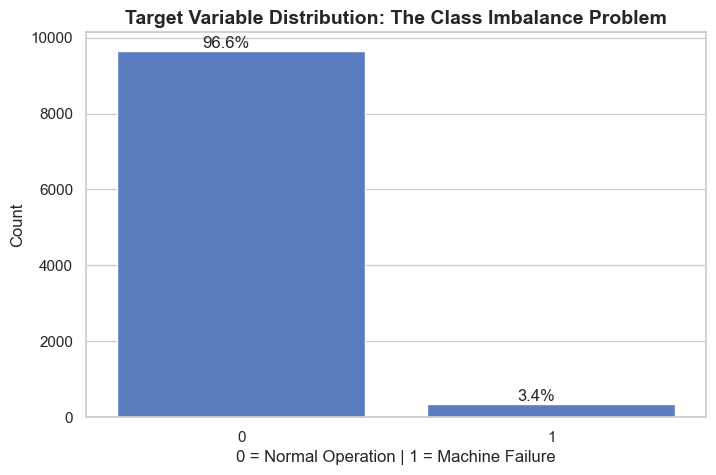

In [8]:
# Visualize the ratio of healthy machines to broken machines
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Machine failure')
plt.title('Target Variable Distribution: The Class Imbalance Problem', fontsize=14, fontweight='bold')
plt.xlabel('0 = Normal Operation | 1 = Machine Failure')
plt.ylabel('Count')

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

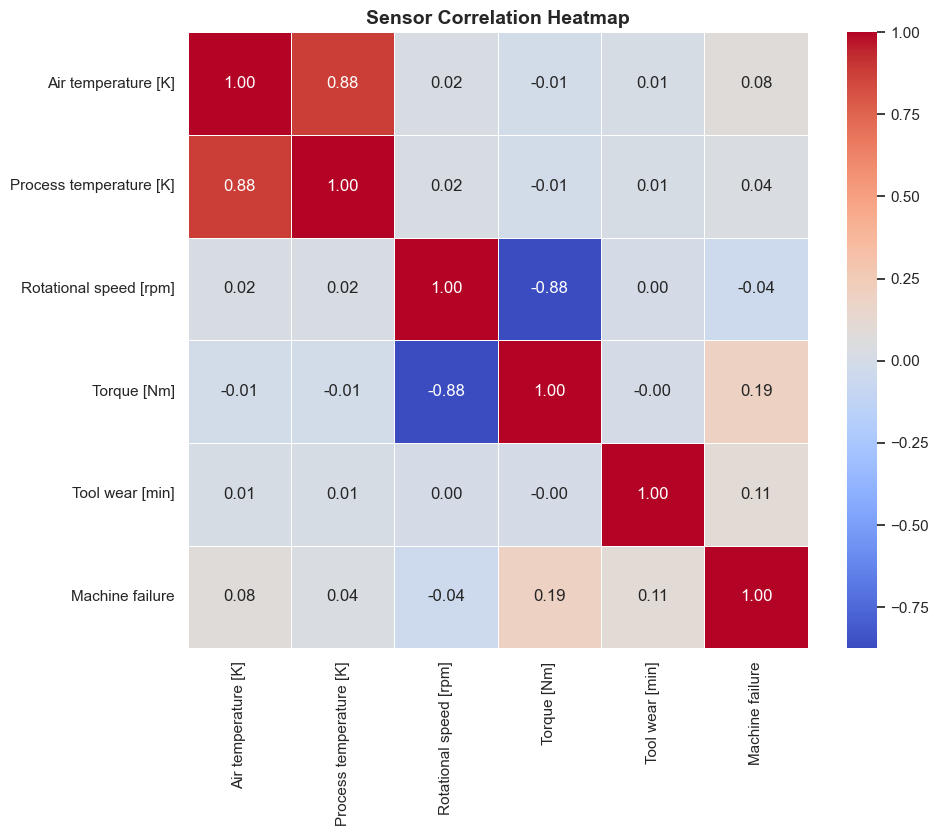

In [9]:
# Drop non-numeric and "cheat" columns to look strictly at physics telemetry
telemetry_cols = ['Air temperature [K]', 'Process temperature [K]', 
                  'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
telemetry_df = df[telemetry_cols]

plt.figure(figsize=(10, 8))
correlation_matrix = telemetry_df.corr()

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sensor Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

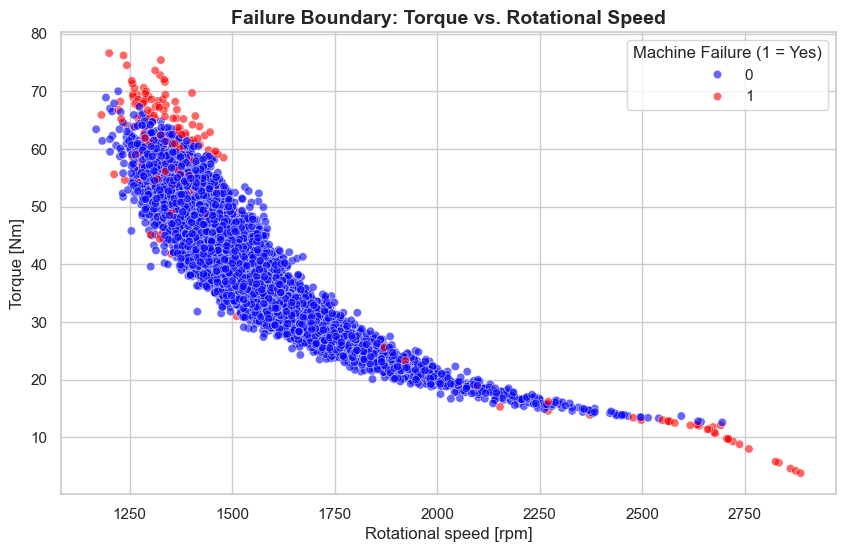

In [10]:
# Visualizing how the relationship between Torque and RPM leads to failure
plt.figure(figsize=(10, 6))

# Scatter plot coloring the points by failure status
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]', 
                hue='Machine failure', alpha=0.6, palette={0: 'blue', 1: 'red'})

plt.title('Failure Boundary: Torque vs. Rotational Speed', fontsize=14, fontweight='bold')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.legend(title='Machine Failure (1 = Yes)')
plt.show()